In [7]:
# Licensed to the Apache Software Foundation (ASF) under one
# or more contributor license agreements.  See the NOTICE file
# distributed with this work for additional information
# regarding copyright ownership.  The ASF licenses this file
# to you under the Apache License, Version 2.0 (the
# "License"); you may not use this file except in compliance
# with the License.  You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing,
# software distributed under the License is distributed on an
# "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY
# KIND, either express or implied.  See the License for the
# specific language governing permissions and limitations
# under the License.

# Coding agent

A minimal coding agent harness: an LLM that reads files, writes files, and runs
shell commands in a loop until the task is done.

The point is the **loop**. A tool-calling assistant runs one tool and hands back
to the user. An agent keeps going by itself -- read a file, edit it, run the
tests, see them fail, try again -- with no human in between. That is a cycle,
and cycles are what Burr is for.

This notebook runs without an API key: a scripted client stands in for the model.

# Imports

In [8]:
import inspect
import json
import os
import subprocess
from typing import Callable, Optional

from burr.core import State, action, expr, when
from burr.core.application import ApplicationBuilder

# The tools

Four functions. Each takes primitive, type-annotated arguments and returns a
dict -- and never raises. An exception would kill the state machine; an
`{"error": ...}` dict goes back to the model, which can then try something else.

Paths are confined to a workspace directory. Note that `run_bash` can `cd` out
of it: this is a teaching example, not a sandbox.

In [9]:
"""Tools the coding agent can call. Each takes typed args and returns a dict."""
# Licensed to the Apache Software Foundation (ASF) under one
# or more contributor license agreements.  See the NOTICE file
# distributed with this work for additional information
# regarding copyright ownership.  The ASF licenses this file
# to you under the Apache License, Version 2.0 (the
# "License"); you may not use this file except in compliance
# with the License.  You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing,
# software distributed under the License is distributed on an
# "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY
# KIND, either express or implied.  See the License for the
# specific language governing permissions and limitations
# under the License.

import inspect
import json
import os
from typing import Callable, Optional

import openai
import requests

from burr.core import State, action, when
from burr.core.application import ApplicationBuilder

import os
import subprocess

# Everything is confined to this directory. See README on why this is not a sandbox.
WORKSPACE = os.environ.get("CODING_AGENT_WORKSPACE", "./workspace")


def _resolve(path: str) -> str:
    """Resolve a path inside the workspace, refusing anything that escapes it."""
    root = os.path.abspath(WORKSPACE)
    full = os.path.abspath(os.path.join(root, path))
    if not full.startswith(root + os.sep) and full != root:
        raise ValueError(f"path escapes workspace: {path}")
    return full


def list_files(directory: str = ".") -> dict:
    """Lists the files and directories at the given path inside the workspace."""
    try:
        target = _resolve(directory)
        return {"entries": sorted(os.listdir(target))}
    except (ValueError, OSError) as e:
        return {"error": str(e)}


def read_file(path: str) -> dict:
    """Reads a text file from the workspace and returns its contents."""
    try:
        with open(_resolve(path)) as f:
            return {"path": path, "contents": f.read()}
    except (ValueError, OSError) as e:
        return {"error": str(e)}


def write_file(path: str, contents: str) -> dict:
    """Writes text to a file in the workspace, creating or overwriting it."""
    try:
        full = _resolve(path)
        os.makedirs(os.path.dirname(full), exist_ok=True)
        with open(full, "w") as f:
            f.write(contents)
        return {"path": path, "bytes_written": len(contents)}
    except (ValueError, OSError) as e:
        return {"error": str(e)}


def run_bash(command: str) -> dict:
    """Runs a shell command in the workspace and returns its output."""
    try:
        proc = subprocess.run(
            command, shell=True, cwd=os.path.abspath(WORKSPACE),
            capture_output=True, text=True, timeout=30,
        )
        return {
            "exit_code": proc.returncode,
            "stdout": proc.stdout[-4000:],
            "stderr": proc.stderr[-4000:],
        }
    except subprocess.TimeoutExpired:
        return {"error": "command timed out after 30s"}
    

# Describing the tools to the model

The schema is derived from signatures and docstrings, so the tools stay the single source of truth. Only parameters without defaults are marked required.

In [10]:
TOOLS = {
    "list_files": list_files,
    "read_file": read_file,
    "write_file": write_file,
    "run_bash": run_bash,
}

In [11]:
TYPE_MAP = {str: "string", int: "integer", float: "number", bool: "boolean"}

OPENAI_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": name,
            "description": fn.__doc__ or name,
            "parameters": {
                "type": "object",
                "properties": {
                    p.name: {
                        "type": TYPE_MAP.get(p.annotation, "string"),
                        "description": p.name,
                    }
                    for p in inspect.signature(fn).parameters.values()
                },
                "required": [
                    p.name
                    for p in inspect.signature(fn).parameters.values()
                    if p.default is inspect.Parameter.empty
                ],
            },
        },
    }
    for name, fn in TOOLS.items()
]

In [12]:
SYSTEM_PROMPT = (
    "You are a coding agent working inside a project directory. "
    "Use the tools to inspect and modify files, and to run commands. "
    "Work one step at a time: look before you edit, and verify changes by running them. "
    "When the task is complete, reply with a short summary and request no tool."
)

# Two clients

Both return the same shape, so the rest of the harness doesn't care which is in
use. The scripted client replays a fixed sequence, which is what lets this
notebook -- and CI -- run with no API key.

In [13]:
class OpenAIClient:
    """Calls OpenAI's chat completions API with tool calling enabled."""

    def __init__(self, model: str = "gpt-4o"):
        self.model = model

    def __call__(self, messages: list[dict]) -> dict:
        import openai

        response = openai.chat.completions.create(
            model=self.model, messages=messages, tools=OPENAI_TOOLS
        )
        message = response.choices[0].message
        calls = [
            {"id": c.id, "name": c.function.name, "args": json.loads(c.function.arguments)}
            for c in (message.tool_calls or [])
        ]
        return {"content": message.content, "tool_calls": calls}


class ScriptedClient:
    """Replays a fixed list of responses. Lets the example run without an API key."""

    def __init__(self, responses: list[dict]):
        self.responses = list(responses)
        self.index = 0

    def __call__(self, messages: list[dict]) -> dict:
        if self.index >= len(self.responses):
            return {"content": "Script exhausted.", "tool_calls": []}
        response = self.responses[self.index]
        self.index += 1
        return response


DEFAULT_SCRIPT = [
    {"content": None, "tool_calls": [{"id": "c1", "name": "list_files", "args": {}}]},
    {
        "content": None,
        "tool_calls": [
            {"id": "c2", "name": "write_file",
             "args": {"path": "hello.py", "contents": "print('hello from the agent')\n"}}
        ],
    },
    {"content": None, "tool_calls": [{"id": "c3", "name": "run_bash",
                                      "args": {"command": "python hello.py"}}]},
    {"content": "Created hello.py and confirmed it runs.", "tool_calls": []},
]


def get_client():
    """Real client when OPENAI_API_KEY is set, otherwise the scripted stand-in."""
    if os.environ.get("OPENAI_API_KEY"):
        return OpenAIClient()
    return ScriptedClient(DEFAULT_SCRIPT)

# The actions

`call_llm` is the interesting one. It appends the model's reply to `messages`,
and either sets `done` (no tool requested) or records which tool to run next.
Tool results come back as `role: "tool"` messages carrying the `tool_call_id`
they answer -- that is how the model sees what its last action returned.

In [14]:
@action(reads=[], writes=["task", "messages", "steps", "done", "final_answer"])
def human_input(state: State, task: str) -> State:
    """Takes a task from the user and starts a fresh run."""
    return state.update(
        task=task,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": task},
        ],
        steps=0,
        done=False,
        final_answer=None,
    )


@action(reads=["messages"], writes=["messages"])
def create_prompt(state: State) -> State:
    """Seam for shaping the prompt before each call -- add file trees, summaries, etc."""
    return state.update(messages=state["messages"])


@action(
    reads=["messages", "steps"],
    writes=["messages", "next_tool", "next_args", "last_tool_call_id",
            "steps", "done", "final_answer"],
)
def call_llm(state: State, client: Callable) -> State:
    """Asks the model what to do next: call a tool, or finish."""
    result = client(state["messages"])
    calls = result["tool_calls"]

    if not calls:
        return state.update(
            messages=state["messages"] + [{"role": "assistant", "content": result["content"]}],
            next_tool=None,
            next_args={},
            last_tool_call_id=None,
            steps=state["steps"] + 1,
            done=True,
            final_answer=result["content"],
        )

    # One tool per iteration keeps the graph readable; extras are dropped.
    call = calls[0]
    assistant_message = {
        "role": "assistant",
        "content": result["content"],
        "tool_calls": [
            {
                "id": call["id"],
                "type": "function",
                "function": {"name": call["name"], "arguments": json.dumps(call["args"])},
            }
        ],
    }
    return state.update(
        messages=state["messages"] + [assistant_message],
        next_tool=call["name"],
        next_args=call["args"],
        last_tool_call_id=call["id"],
        steps=state["steps"] + 1,
        done=False,
        final_answer=None,
    )


@action(reads=["next_args", "last_tool_call_id", "messages"], writes=["messages"])
def execute_tool(state: State, tool_function: Callable) -> State:
    """Runs one tool and feeds its result back to the model."""
    result = tool_function(**state["next_args"])
    return state.update(
        messages=state["messages"]
        + [
            {
                "role": "tool",
                "tool_call_id": state["last_tool_call_id"],
                "content": json.dumps(result),
            }
        ]
    )


@action(reads=["final_answer", "steps", "max_steps"], writes=["final_answer"])
def respond(state: State) -> State:
    """Surfaces the answer, or explains that the budget ran out."""
    if state["final_answer"]:
        return state.update(final_answer=state["final_answer"])
    return state.update(
        final_answer=f"Stopped after {state['steps']} steps without finishing the task."
    )

# Wiring the graph

Two transitions leave `call_llm` for `respond`: the model finished, or the step
budget ran out. Both are listed **before** the tool transitions, because Burr
takes the first matching condition. An agent that picks its own next step can
loop forever, so the budget is not optional.

Each tool is a separately bound action, so the Burr UI shows exactly which one
ran at each step.

In [15]:
def application(app_id: Optional[str] = None, max_steps: int = 15, client: Callable = None):
    """Builds the coding agent application."""
    client = client or get_client()
    return (
        ApplicationBuilder()
        .with_actions(
            human_input,
            create_prompt,
            respond,
            call_llm=call_llm.bind(client=client),
            read_file=execute_tool.bind(tool_function=read_file),
            write_file=execute_tool.bind(tool_function=write_file),
            list_files=execute_tool.bind(tool_function=list_files),
            run_bash=execute_tool.bind(tool_function=run_bash),
        )
        .with_transitions(
            ("human_input", "create_prompt"),
            ("create_prompt", "call_llm"),
            ("call_llm", "respond", when(done=True)),
            ("call_llm", "respond", expr("steps>=max_steps")),
            ("call_llm", "read_file", when(next_tool="read_file")),
            ("call_llm", "write_file", when(next_tool="write_file")),
            ("call_llm", "list_files", when(next_tool="list_files")),
            ("call_llm", "run_bash", when(next_tool="run_bash")),
            (["read_file", "write_file", "list_files", "run_bash"], "call_llm"),
            ("respond", "human_input"),
        )
        .with_state(max_steps=max_steps, steps=0, messages=[], done=False, final_answer=None)
        .with_identifiers(app_id=app_id)
        .with_entrypoint("human_input")
        .with_tracker(project="demo_coding_agent")
        .build()
    )

# Running it

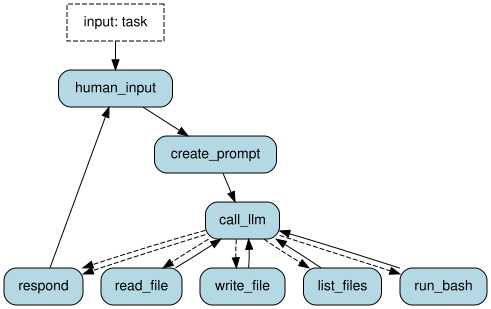

In [16]:
app = application()
app.visualize()

In [17]:
_, _, state = app.run(
    halt_after=["respond"],
    inputs={"task": "Create a hello.py that prints a greeting, then run it."},
)
print(state["final_answer"])

Created hello.py and confirmed it runs.
